In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from typing import Dict, List, Tuple, Optional
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")

# Constants
PARAM_COUNT = 11_191_262
MB_TO_BITS = 1024 ** 2 * 8
reports_dir = Path("reports")

# Plot styling constants
MARKERS = ['o', 's', '^', 'D', 'v', 'X', 'P', '*', 'h', '+']
LINE_STYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']
COLORS = {
    'acc': ['blue', 'navy', 'royalblue', 'steelblue', 'dodgerblue', 'cornflowerblue'],
    'bitrate': ['red', 'darkred', 'crimson', 'firebrick', 'indianred', 'lightcoral'],
    'auc': ['green', 'darkgreen', 'forestgreen', 'seagreen', 'mediumseagreen', 'springgreen'],
    'mape': ['orange', 'darkorange', 'orangered', 'coral', 'tomato', 'lightsalmon']
}

from util import load_data
auc_data, broadcast_data, wz_training_data = load_data()

Loaded data: 4 AUC, 4 broadcast, 3 WZ training


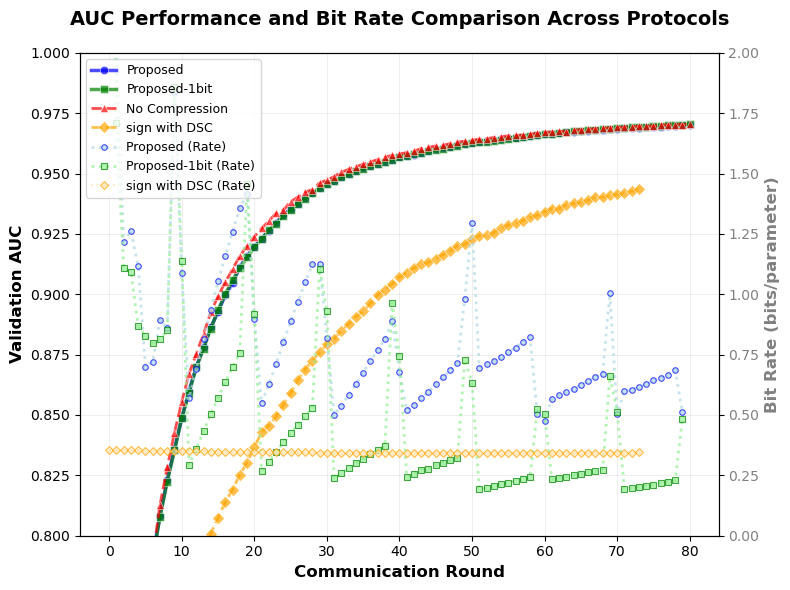

In [14]:

def create_auc_plot(auc_data, broadcast_data):
    """Create AUC plot with dual y-axis showing bit rate for protocols."""

    # Define the protocols we want to include
    target_protocols = ['Proposed', 'Proposed-1bit', 'No Compression', 'sign with DSC', 'Proposed - Without realignment']

    # Filter data to only include target protocols
    filtered_auc_data = {k: auc_data[k] for k in target_protocols if k in auc_data}
    filtered_broadcast_data = {k: broadcast_data[k] for k in target_protocols if k in broadcast_data}

    # Create figure with dual y-axis
    plt.style.use('default')
    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax2 = ax1.twinx()

    # Define styling for each protocol
    protocol_styles = {
        'Proposed': {'color': 'blue', 'marker': 'o', 'linestyle': '-', 'linewidth': 2.5},
        'Proposed-1bit': {'color': 'green', 'marker': 's', 'linestyle': '-', 'linewidth': 2.5},
        'No Compression': {'color': 'red', 'marker': '^', 'linestyle': '--', 'linewidth': 2},
        'sign with DSC': {'color': 'orange', 'marker': 'D', 'linestyle': '--', 'linewidth': 2},
        # 'Proposed - Without realignment': {'color': 'purple', 'marker': 'v', 'linestyle': '-.', 'linewidth': 2},
    }

    # Plot AUC data on primary y-axis
    auc_lines = []
    for protocol, df in filtered_auc_data.items():
        style = protocol_styles[protocol]

        line = ax1.plot(df['round_id'], df['val_auc'],
                       color=style['color'],
                       marker=style['marker'],
                       linestyle=style['linestyle'],
                       linewidth=style['linewidth'],
                       markersize=6,
                       markerfacecolor=style['color'],
                       markeredgecolor='white',
                       markeredgewidth=0.5,
                       label=f'{protocol}',
                       alpha=0.7)
        auc_lines.extend(line)

    # Plot bit rate data on secondary y-axis
    rate_lines = []
    for protocol, df in filtered_broadcast_data.items():
        if protocol in protocol_styles:
            style = protocol_styles[protocol]

            # Use lighter version of the same color for rate
            rate_color_map = {
                'blue': 'lightblue',
                'green': 'lightgreen',
                'purple': 'plum',
                'red': 'lightcoral',
                'orange': 'moccasin'
            }
            rate_color = rate_color_map.get(style['color'], style['color'])

            line = ax2.plot(df['round_id'], df['bit_rate'],
                           color=rate_color,
                           marker=style['marker'],
                           linestyle=':',  # Use dotted line for rate
                           linewidth=style['linewidth']-0.5,
                           markersize=4,
                           markerfacecolor=rate_color,
                           markeredgecolor=style['color'],
                           markeredgewidth=0.8,
                           label=f'{protocol} (Rate)',
                           alpha=0.7)
            rate_lines.extend(line)

    # Formatting for primary y-axis (AUC)
    ax1.set_xlabel('Communication Round', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Validation AUC', fontsize=12, fontweight='bold', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_ylim(0.8, 1)
    # ax1.set_xlim(10, 50)

    # Formatting for secondary y-axis (Bit Rate)
    ax2.set_ylabel('Bit Rate (bits/parameter)', fontsize=12, fontweight='bold', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    # Set bit rate y-axis limits based on data range
    if filtered_broadcast_data:
        all_rates = []
        for df in filtered_broadcast_data.values():
            all_rates.extend(df['bit_rate'].dropna().tolist())
        if all_rates:
            min_rate, max_rate = min(all_rates), max(all_rates)
            rate_range = max_rate - min_rate
            ax2.set_ylim(max(0, min_rate - 0.1*rate_range), max_rate + 0.1*rate_range)

    # Title and grid
    ax1.set_title('AUC Performance and Bit Rate Comparison Across Protocols',
                  fontsize=14, fontweight='bold', pad=20)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

    ax2.set_ylim(0, 2)
    # Combined legend
    lines = auc_lines + rate_lines
    labels = [l.get_label() for l in lines]
    # ax1.legend(lines, labels, loc='upper left', fontsize=9)
    legend = ax2.legend(lines, labels, loc='upper left', fontsize=9)
    legend.get_frame().set_alpha(0.8)  # make legend box fully opaque

    # Improve layout
    plt.tight_layout()

    return fig, ax1, ax2

fig, ax1, ax2 = create_auc_plot(auc_data, broadcast_data)
plt.show()


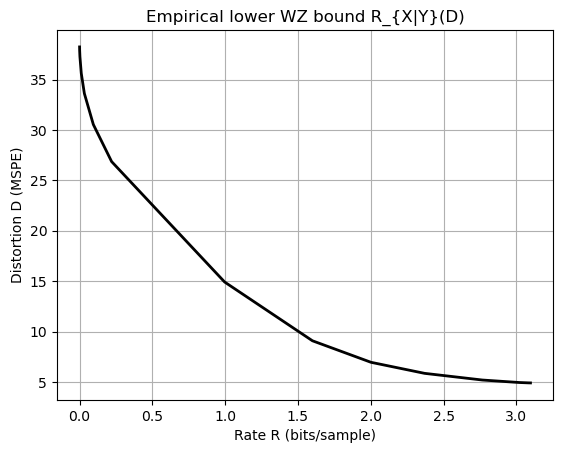

In [151]:
wz_bound = np.load('wz_bound (2).npz')
i=15
wz_bound = {"Rate": wz_bound['R'][:i], "Distortion": wz_bound['D'][:i]-2}
import numpy as np
import matplotlib.pyplot as plt

# sort by D so the curve is monotone left→right
idx = np.argsort(wz_bound['Distortion'])
plt.plot(wz_bound['Rate'][idx], wz_bound['Distortion'][idx], label='WZ Bound', color='black', linewidth=2)
plt.ylabel("Distortion D (MSPE)")
plt.xlabel("Rate R (bits/sample)")
plt.title("Empirical lower WZ bound R_{X|Y}(D)")
plt.grid(True)
plt.show()

In [174]:
data = [broadcast_data['Proposed'], broadcast_data['Proposed-1bit']]
data = [d[d['round_id']>20] for d in data]
# group by round_id//10 and get mean of each group for bit_rate and mape%
data = [d.groupby(d['round_id']//10).agg(
    {'bit_rate': 'mean', 'mape%': 'mean'}).reset_index() for d in data]

# pair points from data[0] and data[1]
points = []
round_number = []
for i in range(len(data[0])):
    points.append([(data[0].iloc[i]['bit_rate'], data[0].iloc[i]['mape%']),
                  (data[1].iloc[i]['bit_rate'], data[1].iloc[i]['mape%'])])
    round_number.append(data[0].iloc[i]['round_id'])
points = np.array(points)

points=[points[0], points[-1]]
round_number = [round_number[0], round_number[-1]]

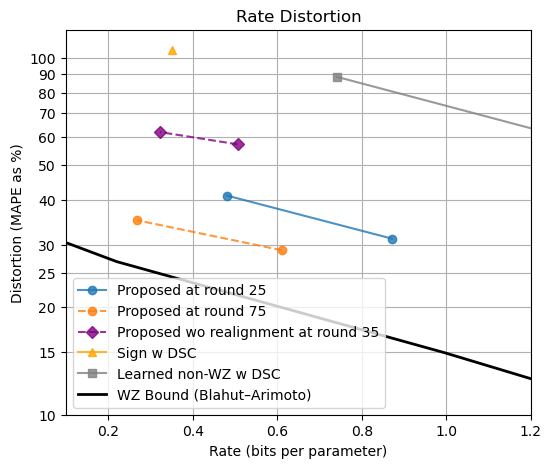

In [180]:
idx = np.argsort(wz_bound['Distortion'])
plt.figure(figsize=(6,5))
plt.style.use('default')

for i, p in enumerate(points):
    plt.plot(p[:,0], p[:,1], marker='o', linestyle='-' if i==0 else '--',
             alpha=0.8, label=f'Proposed at round {int(round_number[i]*10+5)}')

plt.plot([0.506263,0.322704,],[57.272222,61.976250,],  label='Proposed wo realignment at round 35', marker='D', linestyle='--', color='purple', alpha=0.8)

plt.legend()
plt.yscale('log')

name = 'Sign w DSC'
df = broadcast_data['sign with DSC']
mean_point = df[df['round_id']>1]
mean_point = mean_point.groupby(mean_point['round_id']//10).agg(
    {'bit_rate': 'mean', 'mape%': 'mean'}).reset_index()
plt.plot(0.35, 105,
         marker='^', linestyle='-', alpha=0.8, label=name,
         color='orange' if 'Sign' in name else 'slateblue')

plt.plot([0.7404, 1.69],[88.57, 44.57], marker='s', linestyle='-', color='gray', label='Learned non-WZ w DSC', alpha=0.8)

custom_ticks = [5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]
plt.yticks(custom_ticks)
temp=[str(tick) for tick in custom_ticks]
plt.gca().set_yticklabels(temp)

plt.plot(wz_bound['Rate'][idx], wz_bound['Distortion'][idx],
         label='WZ Bound (Blahut–Arimoto)', color='black', linewidth=2)
plt.ylabel("Distortion (MAPE as %)")
plt.xlabel("Rate (bits per parameter)")
plt.title('Rate Distortion')
plt.legend(loc='best')
plt.grid(True)
plt.xlim(0.1,1.2)
plt.ylim(10, 120)
plt.show()

Protocol Statistics (excluding round 1):
------------------------------------------------------------
Proposed:
  Average Rate: 0.7749 bits/param
  Average MAPE: 29.06%
  Data points: 73

Proposed - Without realignment:
  Average Rate: 0.7644 bits/param
  Average MAPE: 52.00%
  Data points: 43

Proposed-1bit:
  Average Rate: 0.4450 bits/param
  Average MAPE: 37.02%
  Data points: 73

sign with DSC:
  Average Rate: 0.3452 bits/param
  Average MAPE: 96.29%
  Data points: 67



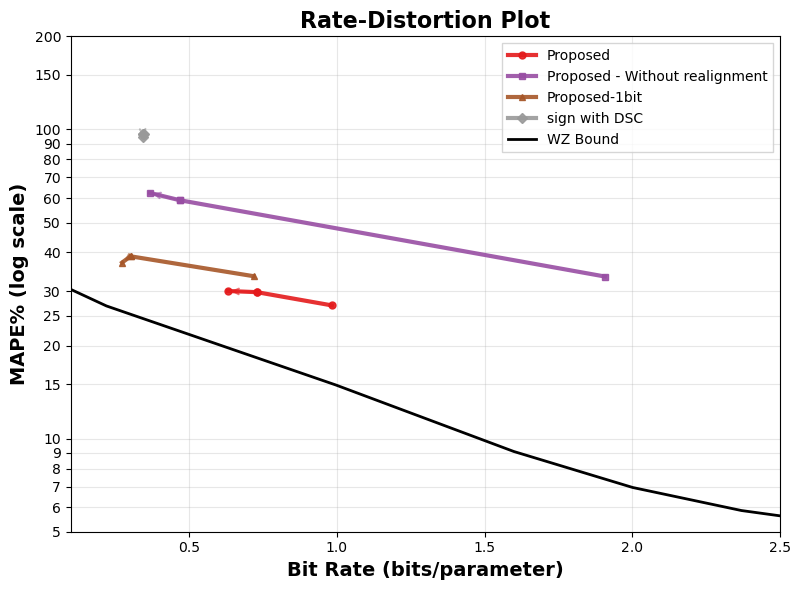

In [154]:

# Rate Distortion Plot with Average Points and Distribution
def create_rate_distortion_with_distribution(fig, ax):
    """Create a rate distortion plot showing average points per protocol."""


    # Color palette for different protocols
    protocol_colors = plt.cm.Set1(np.linspace(0, 1, len(broadcast_data)))

    protocol_stats = {}

    for i, (exp_name, df) in enumerate(broadcast_data.items()):
        # Filter out round 1 (ignore first round)
        df_filtered = df.copy()
        if exp_name!='Simple':
            df_filtered = df_filtered[df_filtered['round_id'] > 6]
            # df_filtered = df_filtered[df_filtered['round_id'] < 47]


        if len(df_filtered) == 0:
            continue

        # Extract rate and mape data
        if 'bit_rate' in df_filtered.columns and 'mape%' in df_filtered.columns:
            rates = df_filtered['bit_rate'].dropna()
            mapes = df_filtered['mape%'].dropna()

            # Only proceed if we have valid data
            if len(rates) > 0 and len(mapes) > 0:
                # Calculate average point
                avg_rate = rates.mean()
                avg_mape = mapes.mean()

                # Store protocol statistics
                protocol_stats[exp_name] = {
                    'avg_rate': avg_rate,
                    'avg_mape': avg_mape,
                    'rates': rates.values,
                    'mapes': mapes.values,
                    'color': protocol_colors[i],
                    'marker': MARKERS[i % len(MARKERS)]
                }

    # ---------- Plot individual data points for each protocol (without adding to legend)
    # for exp_name, stats in protocol_stats.items():
    #     # Plot all individual points with more faint markers (no label for legend)
    #     ax.scatter(stats['rates'], stats['mapes'],
    #               c=[stats['color']], marker=stats['marker'],
    #               s=20, alpha=0.2, zorder=3)

    # ---------- Create individual density plots per protocol
    # from scipy.stats import gaussian_kde
    #
    # for exp_name, stats in protocol_stats.items():
    #     if len(stats['rates']) > 5:  # Need minimum points for KDE
    #         rates = stats['rates']
    #         mapes = stats['mapes']
    #
    #         # Create KDE for this protocol
    #         points = np.vstack([rates, mapes])
    #         kde = gaussian_kde(points)
    #
    #         # Create grid for this protocol's density
    #         rate_min, rate_max = rates.min(), rates.max()
    #         mape_min, mape_max = mapes.min(), mapes.max()
    #
    #         # Add padding
    #         rate_range = max(rate_max - rate_min, 0.01)
    #         mape_range = max(mape_max - mape_min, 0.01)
    #
    #         rate_grid = np.linspace(rate_min - 0.1*rate_range, rate_max + 0.1*rate_range, 30)
    #         mape_grid = np.linspace(mape_min - 0.1*mape_range, mape_max + 0.1*mape_range, 30)
    #
    #         Rate_grid, Mape_grid = np.meshgrid(rate_grid, mape_grid)
    #         grid_coords = np.vstack([Rate_grid.ravel(), Mape_grid.ravel()])
    #         density = kde(grid_coords).reshape(Rate_grid.shape)
    #
    #         # Filter out low density areas to prevent large boxes
    #         max_density = density.max()
    #         threshold = max_density * 0.25  # Only show areas with at least 30% of max density
    #         density_filtered = density.copy()
    #         density_filtered[density_filtered < threshold] = 0
    #
    #         # Plot only contour lines (no filled contours to avoid boxes)
    #         if density_filtered.max() > 0:
    #             ax.contour(Rate_grid, Mape_grid, density_filtered,
    #                       levels=3, colors=[stats['color']], alpha=0.4, linewidths=0.8,
    #                        linestyles='dashed')

    # ---------- Plot average points for each protocol (main legend entries)
    # for exp_name, stats in protocol_stats.items():
    #     ax.scatter(stats['avg_rate'], stats['avg_mape'],
    #               c=[stats['color']], marker=stats['marker'],
    #               s=100, alpha=0.95,
    #               label=f'{exp_name}', zorder=5)

    # ---------- Add connected segmented evolution arrows for each protocol (every 8 rounds)
    for exp_name, stats in protocol_stats.items():
        rates = stats['rates']
        mapes = stats['mapes']

        centers = []
        steps_c = (len(rates)-3)//4
        for j in range(0,len(rates), steps_c):
            centers.append((rates[j:j+steps_c].mean(), mapes[j:j+steps_c].mean()))
        centers = np.array(centers)

        centers = centers[::2]
        for c in range(0,len(centers)-1):
            plt.plot([centers[c,0], centers[c+1,0]], [centers[c,1], centers[c+1,1]],
                     color=stats['color'], alpha=0.9, lw=3, linestyle='-', zorder=4,
                     marker=stats['marker'], markersize=5,
                     label=exp_name if c==0 else None)
        ax.annotate("",
                    xy=(centers[c+1,0], centers[c+1,1]),
                    xytext=(centers[c,0], centers[c,1]),
                    arrowprops=dict(arrowstyle="->", color=stats['color'], lw=1.5, alpha=0.6),
                    alpha=0.4,
                    )

    # ---------- Formatting
    ax.set_xlabel('Bit Rate (bits/parameter)', fontsize=14, fontweight='bold')
    ax.set_ylabel('MAPE% (log scale)', fontsize=14, fontweight='bold')
    ax.set_yscale('log')

    # Add more y-axis ticks for better readability
    from matplotlib.ticker import LogLocator, LogFormatter
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=15))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), numticks=50))
    ax.yaxis.set_major_formatter(LogFormatter())

    # Add custom tick values for even more granularity
    custom_ticks = [5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]
    ax.set_yticks(custom_ticks)
    ax.set_yticklabels([str(tick) for tick in custom_ticks])

    ax.set_title('Rate-Distortion Plot', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Move legend to top right inside the plot area with better spacing
    ax.legend(loc='upper right', fontsize=8, ncol=1,
             frameon=True, fancybox=False, shadow=False,
             columnspacing=1.0, handlelength=2.0, handletextpad=0.5,
             borderpad=0.8, labelspacing=1)

    # Improve layout
    plt.tight_layout()

    # Print statistics
    print("Protocol Statistics (excluding round 1):")
    print("-" * 60)
    for exp_name, stats in protocol_stats.items():
        print(f"{exp_name}:")
        print(f"  Average Rate: {stats['avg_rate']:.4f} bits/param")
        print(f"  Average MAPE: {stats['avg_mape']:.2f}%")
        print(f"  Data points: {len(stats['rates'])}")
        print()

    return fig, ax


# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
fig, ax = create_rate_distortion_with_distribution(fig, ax)
plt.plot(wz_bound['Rate'][idx], wz_bound['Distortion'][idx], label='WZ Bound', color='black', linewidth=2)
plt.legend(loc='upper right', fontsize=10, frameon=True, fancybox=False, shadow=False,)
plt.xlim(0.1,2.5)
plt.ylim(5, 200)
plt.show()
